In [1]:
import numpy as np
import uproot


def get_centroid_array(
    file_numbers, obj_name="ADC_HIGH_7", base_path="slitA-008-{:03d}.root"
):
    """slitB0-[001].root から指定した番号順に重心の数列（NumPy配列）を返します。

    Parameters:
    -----------
    file_numbers : list or iterable
        取得したいファイル番号のリスト（例: range(0, 10)）
    obj_name : str, default "ADC_HIGH_7"
        読み出すヒストグdラム名
    base_path : str
        ファイル名のパターン（{:03d} は3桁ゼロパディング）

    Returns:
    --------
    np.ndarray
        重心（Mean）が順番に格納された1次元NumPy配列
    """
    centroids = []

    for n in file_numbers:
        file_name = base_path.format(n)

        try:
            with uproot.open(file_name) as f:
                hist = f[obj_name]
                values = hist.values()
                x_edges = hist.axes[0].edges()

            x_centers = (x_edges[:-1] + x_edges[1:]) / 2.0
            total_counts = np.sum(values)

            if total_counts > 0:
                mean = np.sum(x_centers * values) / total_counts
            else:
                mean = np.nan

            centroids.append(mean)

        except Exception:
            # ファイルが存在しない・読み込めない場合は nan を追加
            centroids.append(np.nan)

    return np.array(centroids)

min no 28 ,ave 833.5058
max no 14 ,ave 908.6197
120


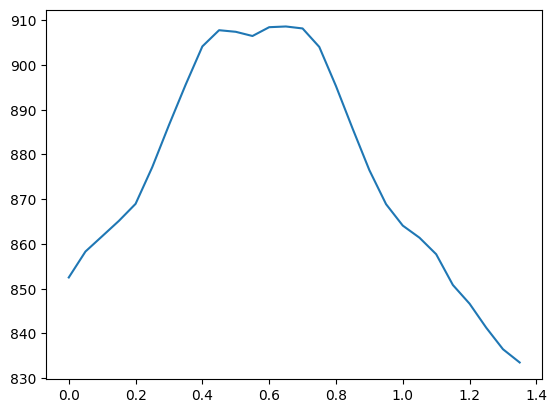

In [2]:
import matplotlib.pyplot as plt
import numpy as np

file_numbers = range(1, 121)
sama = get_centroid_array(file_numbers)
x = np.arange(0, 6.00, 0.05)

minnum = np.nanargmin(sama)
maxnum = np.nanargmax(sama)
print("min no",file_numbers[minnum],",ave",sama[minnum])
print("max no",file_numbers[maxnum],",ave",sama[maxnum])
print(file_numbers[119])
plt.plot(x,sama)
plt.show()

Text(0.5, 1.0, 'Max and min average plot')

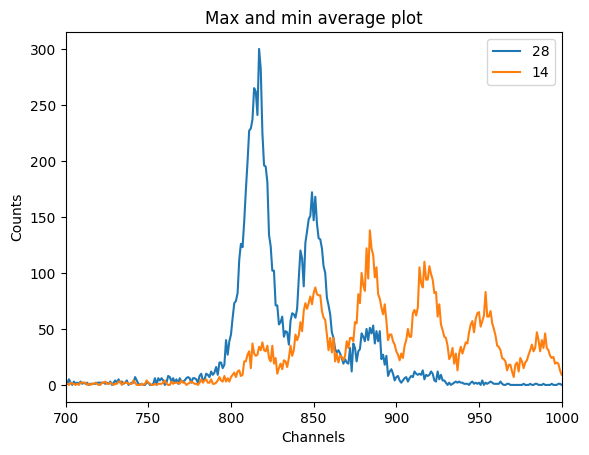

In [4]:
def plotdata(num, obj_name="ADC_HIGH_7",base_path="slitA-008-{:03d}.root"):
    file_name = base_path.format(num)
    index = num-1
    with uproot.open(file_name) as f:
        hist = f[obj_name]
        values = hist.values()
        x_edges = hist.axes[0].edges()

    total_counts = np.sum(values)

    plt.plot(values,label=num)
    plt.xlim(700,1000)
    return values

plotdata(file_numbers[minnum])
plotdata(file_numbers[maxnum])
plt.legend()
plt.xlabel("Channels")
plt.ylabel("Counts")
plt.title("Max and min average plot")

MIN -> File #28 (1.40 cm), Centroid: 833.5058
MAX -> File #14 (0.70 cm), Centroid: 908.6197


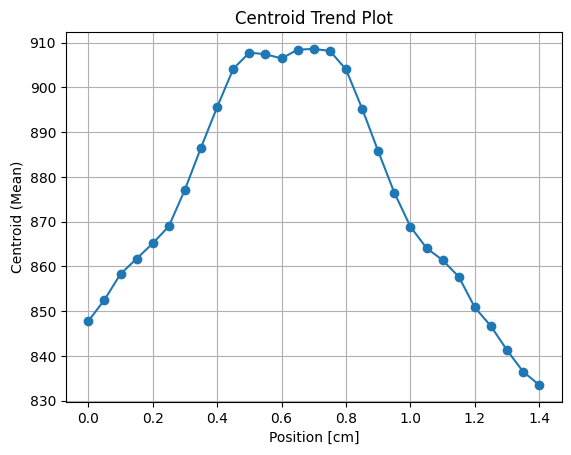

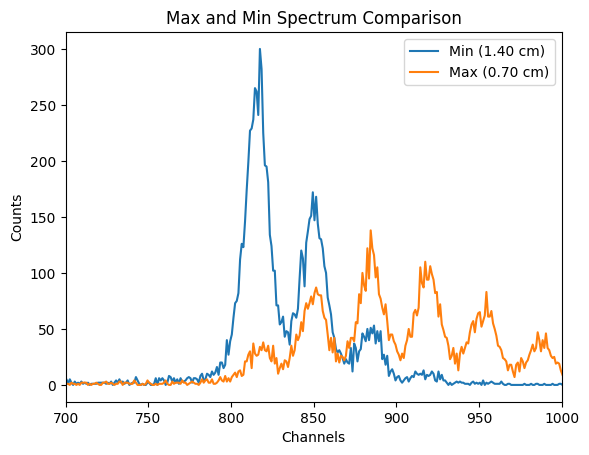

In [11]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import uproot

logging.basicConfig(level=logging.INFO)


# ==========================================
# 1. 位置座標変換ユーティリティ
# ==========================================
def file_num_to_position(
    file_numbers, step: float = 0.05, start_pos: float = 0.0
) -> np.ndarray:
    """ファイル番号のシーケンスを実空間の位置配列（例: cm）に変換

    Parameters:
    -----------
    file_numbers : list or iterable
        ファイル番号のリスト（例: range(1, 121)）
    step : float, default 0.05
        1ファイルあたりの移動間隔（例: 0.05 cm）
    start_pos : float, default 0.0
        最初のファイル（先頭要素）に対応する開始位置

    Returns:
    --------
    np.ndarray
        変換された位置の1次元配列
    """
    file_nums = np.array(file_numbers)
    # 先頭要素からの相対インデックスをベースに位置を算出
    indices = file_nums - file_nums[0]
    return start_pos + indices * step


# ==========================================
# 2. ROOTデータ取得・解析ロジック
# ==========================================
def read_histogram_data(file_path: str, obj_name: str = "ADC_HIGH_7"):
    """ROOTファイルから指定オブジェクトのヒストグラム値とx軸BIN中心を取得"""
    with uproot.open(file_path) as f:
        hist = f[obj_name]
        values, edges = hist.to_numpy()
        x_centers = (edges[:-1] + edges[1:]) / 2.0
        return values, x_centers


def calculate_centroid(values: np.ndarray, x_centers: np.ndarray) -> float:
    """ヒストグラムの値と座標から重心（Mean）を計算"""
    total_counts = np.sum(values)
    if total_counts > 0:
        return float(np.sum(x_centers * values) / total_counts)
    return np.nan


def get_single_centroid(
    file_path: str, obj_name: str = "ADC_HIGH_7"
) -> float:
    """単一ROOTファイルから重心を取得"""
    try:
        values, x_centers = read_histogram_data(file_path, obj_name)
        return calculate_centroid(values, x_centers)
    except Exception as e:
        logging.warning(f"Failed to process {file_path}: {e}")
        return np.nan


def get_centroid_array(
    file_numbers,
    base_path: str = "slitA-008-{:03d}.root",
    obj_name: str = "ADC_HIGH_7",
) -> np.ndarray:
    """複数ファイル番号から順に重心の配列を取得"""
    centroids = [
        get_single_centroid(base_path.format(n), obj_name) for n in file_numbers
    ]
    return np.array(centroids)


# ==========================================
# 3. 描画用プロット関数群
# ==========================================
def plot_centroid_trend(
    file_numbers,
    centroids: np.ndarray,
    step: float = None,
    start_pos: float = 0.0,
    unit: str = "cm",
    ax=None,
    **kwargs,
):
    """重心の推移をプロット（step指定の有無で横軸を位置／ファイル番号に切替）"""
    if ax is None:
        ax = plt.gca()

    if step is not None:
        x = file_num_to_position(file_numbers, step=step, start_pos=start_pos)
        xlabel = f"Position [{unit}]"
    else:
        x = np.array(file_numbers)
        xlabel = "File Number"

    line = ax.plot(
        x, centroids, marker=kwargs.pop("marker", "o"), **kwargs
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Centroid (Mean)")
    ax.set_title("Centroid Trend Plot")
    ax.grid(True)
    return line


def plot_histogram(
    file_num: int,
    base_path: str = "slitA-008-{:03d}.root",
    obj_name: str = "ADC_HIGH_7",
    use_x_centers: bool = True,
    label: str = None,
    ax=None,
    **kwargs,
) -> np.ndarray:
    """指定したファイル番号のヒストグラムを描画"""
    if ax is None:
        ax = plt.gca()

    file_name = base_path.format(file_num)
    values, x_centers = read_histogram_data(file_name, obj_name)

    x_axis = x_centers if use_x_centers else np.arange(len(values))
    plot_label = label if label is not None else f"File #{file_num}"

    ax.plot(x_axis, values, label=plot_label, **kwargs)
    return values

# パラメータ設定
file_numbers = list(range(0, 29))
base_path = "slitA-008-{:03d}.root"
obj_name = "ADC_HIGH_7"
step_cm = 0.05  # 1ファイルあたり 0.05 cm

# 1. 重心アレイの取得
centroids = get_centroid_array(file_numbers, base_path, obj_name)

# 位置アレイの計算（単体で必要な場合）
positions = file_num_to_position(file_numbers, step=step_cm, start_pos=0.0)

# 2. 最小・最大の特定
min_idx = np.nanargmin(centroids)
max_idx = np.nanargmax(centroids)

print(
    f"MIN -> File #{file_numbers[min_idx]} ({positions[min_idx]:.2f} cm), "
    f"Centroid: {centroids[min_idx]:.4f}"
)
print(
    f"MAX -> File #{file_numbers[max_idx]} ({positions[max_idx]:.2f} cm), "
    f"Centroid: {centroids[max_idx]:.4f}"
)

# 3. 横軸を「位置(cm)」にして重心推移を描画
plt.figure()
plot_centroid_trend(
    file_numbers, centroids, step=step_cm, start_pos=0.0, unit="cm"
)
plt.savefig("centroid.png")
plt.show()

# 4. 最小・最大のスペクトル比較（位置ラベルを凡例に付記）
fig, ax = plt.subplots()
plot_histogram(
    file_numbers[min_idx],
    base_path,
    obj_name,
    ax=ax,
    label=f"Min ({positions[min_idx]:.2f} cm)",
)
plot_histogram(
    file_numbers[max_idx],
    base_path,
    obj_name,
    ax=ax,
    label=f"Max ({positions[max_idx]:.2f} cm)",
)

ax.set_xlim(700, 1000)
ax.set_xlabel("Channels")
ax.set_ylabel("Counts")
ax.set_title("Max and Min Spectrum Comparison")
ax.legend()
plt.savefig("Maxmin.png")
plt.show()